In [127]:
START_DATE = '2017-01-02'
END_DATE = '2024-09-01'

In [128]:
# Não apagar. recomendo usar essa lib para pegar os dados da SELIC e IPCA!
! pip install python-bcb


[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: python3.10 -m pip install --upgrade pip


# Imports

In [129]:
# Importar as bibliotecas sugeridas para esta prática
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from bcb import currency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler


import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

# TD

In [130]:
anos = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

In [131]:
def adjust_ntnb_format(dfi: pd.DataFrame):
  # Ajustar a taxa, está em %, vamos colocar em x.xx
  dfi['Taxa Compra Manhã'] = 100*dfi['Taxa Compra Manhã']
  dfi['Taxa Venda Manhã'] = 100*dfi['Taxa Venda Manhã']
  return dfi

In [132]:
dfs = []
for year in anos:
  dfs.append(pd.read_excel(f"./TDIPCA2045/NTN-B_Principal_{year}.xlsx", sheet_name='NTN-B Princ 150545', skiprows=1))

ntnb_df = pd.concat(dfs, ignore_index=True)
ntnb_df = adjust_ntnb_format(ntnb_df)

In [133]:
ntnb_df.head(5)

,Dia,Taxa Compra Manhã,Taxa Venda Manhã,PU Compra Manhã,PU Venda Manhã,PU Base Manhã
0,08/02/2017,5.34,5.46,685.78,664.14,663.92
1,09/02/2017,5.27,5.39,698.96,676.90,676.67
2,10/02/2017,5.21,5.33,710.67,688.23,687.84
3,13/02/2017,5.21,5.33,710.90,688.46,688.23
4,14/02/2017,5.22,5.34,709.23,686.85,686.62


In [134]:
ntnb_df.tail(5)

,Dia,Taxa Compra Manhã,Taxa Venda Manhã,PU Compra Manhã,PU Venda Manhã,PU Base Manhã
1825,17/06/2024,6.31,6.43,1202.68,1174.38,1174.38
1826,18/06/2024,6.36,6.48,1191.41,1163.38,1163.38
1827,19/06/2024,6.36,6.48,1191.83,1163.80,1163.80
1828,20/06/2024,6.28,6.40,1211.05,1182.56,1182.56
1829,21/06/2024,6.29,6.41,1209.38,1180.67,1180.67


Selecionando as colunas, convertendo a data em datetime:

In [135]:
# (1) - NTN-B
col1 = ntnb_df

In [136]:
col1['Dia'] = pd.to_datetime(col1['Dia'], format='%d/%m/%Y')
col1.rename(columns={'Dia': 'Date'}, inplace=True)

In [137]:
col1 = col1[(col1['Date'] >= START_DATE) & (col1['Date'] <= END_DATE)]

In [138]:
col1.head(3)

,Date,Taxa Compra Manhã,Taxa Venda Manhã,PU Compra Manhã,PU Venda Manhã,PU Base Manhã
0,2017-02-08,5.34,5.46,685.78,664.14,663.92
1,2017-02-09,5.27,5.39,698.96,676.90,676.67
2,2017-02-10,5.21,5.33,710.67,688.23,687.84


In [139]:
len(col1)

1830

In [140]:
ntnb = col1
ntnb.set_index('Date', inplace=True)
ntnb.head()

,Taxa Compra Manhã,Taxa Venda Manhã,PU Compra Manhã,PU Venda Manhã,PU Base Manhã
Date,,,,,
2017-02-08,5.34,5.46,685.78,664.14,663.92
2017-02-09,5.27,5.39,698.96,676.90,676.67
2017-02-10,5.21,5.33,710.67,688.23,687.84
2017-02-13,5.21,5.33,710.90,688.46,688.23
2017-02-14,5.22,5.34,709.23,686.85,686.62


In [141]:
# fig = px.line(ntnb, x=ntnb.index, y='PU Compra Manhã', title='Título Tesouro IPCA+2024 (NTN-B Principal 2024)')
# fig = px.line(ntnb, x=ntnb.index, y='PU Venda Manhã', title='Título Tesouro IPCA+2024 (NTN-B Principal 2024)')
# fig

fig = px.line(ntnb, x=ntnb.index, y='PU Compra Manhã', title='IPCA+ 2045 PU Compra e Venda')

# Add the second column to the same figure
fig.add_scatter(x=ntnb.index, y=ntnb['PU Venda Manhã'], mode='lines', name='Column2')

fig.show()

In [142]:
ntnb.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1830 entries, 2017-02-08 to 2024-06-21
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Taxa Compra Manhã  1830 non-null   float64
 1   Taxa Venda Manhã   1830 non-null   float64
 2   PU Compra Manhã    1830 non-null   float64
 3   PU Venda Manhã     1830 non-null   float64
 4   PU Base Manhã      1830 non-null   float64
dtypes: float64(5)
memory usage: 85.8 KB


# PETR3

In [143]:
START_DATE_PETR3 = '2000-01-03'
END_DATE_PETR3 = '2024-06-21'

years_petr3 = range(2000, 2025)

In [144]:
def prepare_petr3_dataset(dfi: pd.DataFrame) -> pd.DataFrame:
#   dfi = dfi.filter(items=['Date', 'Close'])

  dfi['Date'] = pd.to_datetime(dfi['Date'], format='%Y-%m-%d')

  # starting_df = starting_df[(starting_df['Date'] >= START_DATE) & (starting_df['Date'] <= END_DATE)]

  dfi.set_index('Date', inplace=True)

  return dfi

In [145]:
petr3 = pd.read_csv(f"./PETR3.csv")
petr3.dropna(inplace=True)
petr3 = prepare_petr3_dataset(petr3)
petr3.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2000-01-03,4.593750,4.593750,4.593750,4.593750,1.369072,3.998720e+09
2000-01-04,4.335937,4.335937,4.335937,4.335937,1.292236,3.098880e+09
2000-01-05,4.394531,4.394531,4.394531,4.394531,1.309699,6.645760e+09
2000-01-06,4.359375,4.359375,4.359375,4.359375,1.299221,3.303680e+09
2000-01-07,4.394531,4.394531,4.394531,4.394531,1.309699,2.506240e+09


In [146]:
px.line(petr3, x=petr3.index, y='Close', title='Fechamento Diário PETR3 desde 03/01/2000 até 21/06/2024')

In [147]:
petr3["Return"] = (petr3["Close"] / petr3.shift(1)["Close"]) - 1

In [148]:
px.line(petr3, x=petr3.index, y='Return', title='Retorno Diário PETR3 desde 04/01/2000 até 21/06/2024')

In [149]:
petr3.describe()

,Open,High,Low,Close,Adj Close,Volume,Return
count,6145.000000,6145.000000,6145.000000,6145.000000,6145.000000,6.145000e+03,6144.000000
mean,21.706864,22.014960,21.383068,21.692876,8.467126,7.646420e+07,0.000719
std,11.465607,11.659852,11.255733,11.459315,7.111764,4.878221e+08,0.027239
min,3.914062,3.914062,3.914062,3.914062,1.166505,0.000000e+00,-0.296758
25%,12.143750,12.318750,12.037500,12.138750,3.828558,5.139200e+06,-0.013232
50%,21.270000,21.639999,20.850000,21.270000,6.942594,1.120200e+07,0.000000
75%,29.650000,30.150000,29.219999,29.719999,10.352265,2.552540e+07,0.014342
max,62.529999,63.900002,61.830002,62.299999,43.288746,9.756160e+09,0.227554


## Close Lag Experiment

In [150]:
for i in range(1,6):
    petr3[f"Close_lag_{i}"] = petr3["Close"].shift(i)
petr3.drop(["Open", "High", "Low", "Adj Close", "Volume", "Return"], axis=1, inplace=True)
petr3.head(20)

,Close,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_4,Close_lag_5
Date,,,,,,
2000-01-03,4.593750,NaN,NaN,NaN,NaN,NaN
2000-01-04,4.335937,4.593750,NaN,NaN,NaN,NaN
2000-01-05,4.394531,4.335937,4.593750,NaN,NaN,NaN
2000-01-06,4.359375,4.394531,4.335937,4.593750,NaN,NaN
2000-01-07,4.394531,4.359375,4.394531,4.335937,4.593750,NaN
2000-01-10,4.523437,4.394531,4.359375,4.394531,4.335937,4.593750
2000-01-11,4.371093,4.523437,4.394531,4.359375,4.394531,4.335937
2000-01-12,4.218750,4.371093,4.523437,4.394531,4.359375,4.394531
2000-01-13,4.218750,4.218750,4.371093,4.523437,4.394531,4.359375


In [151]:
petr3.dropna(inplace=True)
petr3.head(20)

,Close,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_4,Close_lag_5
Date,,,,,,
2000-01-10,4.523437,4.394531,4.359375,4.394531,4.335937,4.593750
2000-01-11,4.371093,4.523437,4.394531,4.359375,4.394531,4.335937
2000-01-12,4.218750,4.371093,4.523437,4.394531,4.359375,4.394531
2000-01-13,4.218750,4.218750,4.371093,4.523437,4.394531,4.359375
2000-01-14,4.253906,4.218750,4.218750,4.371093,4.523437,4.394531
2000-01-17,4.218750,4.253906,4.218750,4.218750,4.371093,4.523437
2000-01-18,4.218750,4.218750,4.253906,4.218750,4.218750,4.371093
2000-01-19,4.183593,4.218750,4.218750,4.253906,4.218750,4.218750
2000-01-20,4.042968,4.183593,4.218750,4.218750,4.253906,4.218750


In [152]:
petr3.shape

(6140, 6)

In [153]:
petr3 = pd.read_csv(f"./PETR3.csv")
petr3.dropna(inplace=True)
petr3 = prepare_petr3_dataset(petr3)
petr3.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2000-01-03,4.593750,4.593750,4.593750,4.593750,1.369072,3.998720e+09
2000-01-04,4.335937,4.335937,4.335937,4.335937,1.292236,3.098880e+09
2000-01-05,4.394531,4.394531,4.394531,4.394531,1.309699,6.645760e+09
2000-01-06,4.359375,4.359375,4.359375,4.359375,1.299221,3.303680e+09
2000-01-07,4.394531,4.394531,4.394531,4.394531,1.309699,2.506240e+09


In [154]:
for i in range(1,6):
    petr3[f"Close_lag_{i}"] = petr3["Close"].shift(i)
    petr3[f"Volume_lag_{i}"] = petr3["Volume"].shift(i)
petr3.drop(["Open", "High", "Low", "Adj Close"], axis=1, inplace=True)
petr3.head(20)

,Close,Volume,Close_lag_1,Volume_lag_1,Close_lag_2,Volume_lag_2,Close_lag_3,Volume_lag_3,Close_lag_4,Volume_lag_4,Close_lag_5,Volume_lag_5
Date,,,,,,,,,,,,
2000-01-03,4.593750,3.998720e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,4.335937,3.098880e+09,4.593750,3.998720e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,4.394531,6.645760e+09,4.335937,3.098880e+09,4.593750,3.998720e+09,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-06,4.359375,3.303680e+09,4.394531,6.645760e+09,4.335937,3.098880e+09,4.593750,3.998720e+09,NaN,NaN,NaN,NaN
2000-01-07,4.394531,2.506240e+09,4.359375,3.303680e+09,4.394531,6.645760e+09,4.335937,3.098880e+09,4.593750,3.998720e+09,NaN,NaN
2000-01-10,4.523437,2.247680e+09,4.394531,2.506240e+09,4.359375,3.303680e+09,4.394531,6.645760e+09,4.335937,3.098880e+09,4.593750,3.998720e+09
2000-01-11,4.371093,1.834240e+09,4.523437,2.247680e+09,4.394531,2.506240e+09,4.359375,3.303680e+09,4.394531,6.645760e+09,4.335937,3.098880e+09
2000-01-12,4.218750,3.682560e+09,4.371093,1.834240e+09,4.523437,2.247680e+09,4.394531,2.506240e+09,4.359375,3.303680e+09,4.394531,6.645760e+09
2000-01-13,4.218750,1.482240e+09,4.218750,3.682560e+09,4.371093,1.834240e+09,4.523437,2.247680e+09,4.394531,2.506240e+09,4.359375,3.303680e+09


In [155]:
petr3.dropna(inplace=True)
petr3.head(20)

,Close,Volume,Close_lag_1,Volume_lag_1,Close_lag_2,Volume_lag_2,Close_lag_3,Volume_lag_3,Close_lag_4,Volume_lag_4,Close_lag_5,Volume_lag_5
Date,,,,,,,,,,,,
2000-01-10,4.523437,2.247680e+09,4.394531,2.506240e+09,4.359375,3.303680e+09,4.394531,6.645760e+09,4.335937,3.098880e+09,4.593750,3.998720e+09
2000-01-11,4.371093,1.834240e+09,4.523437,2.247680e+09,4.394531,2.506240e+09,4.359375,3.303680e+09,4.394531,6.645760e+09,4.335937,3.098880e+09
2000-01-12,4.218750,3.682560e+09,4.371093,1.834240e+09,4.523437,2.247680e+09,4.394531,2.506240e+09,4.359375,3.303680e+09,4.394531,6.645760e+09
2000-01-13,4.218750,1.482240e+09,4.218750,3.682560e+09,4.371093,1.834240e+09,4.523437,2.247680e+09,4.394531,2.506240e+09,4.359375,3.303680e+09
2000-01-14,4.253906,1.480960e+09,4.218750,1.482240e+09,4.218750,3.682560e+09,4.371093,1.834240e+09,4.523437,2.247680e+09,4.394531,2.506240e+09
2000-01-17,4.218750,7.449600e+08,4.253906,1.480960e+09,4.218750,1.482240e+09,4.218750,3.682560e+09,4.371093,1.834240e+09,4.523437,2.247680e+09
2000-01-18,4.218750,9.420800e+08,4.218750,7.449600e+08,4.253906,1.480960e+09,4.218750,1.482240e+09,4.218750,3.682560e+09,4.371093,1.834240e+09
2000-01-19,4.183593,2.808320e+09,4.218750,9.420800e+08,4.218750,7.449600e+08,4.253906,1.480960e+09,4.218750,1.482240e+09,4.218750,3.682560e+09
2000-01-20,4.042968,2.941440e+09,4.183593,2.808320e+09,4.218750,9.420800e+08,4.218750,7.449600e+08,4.253906,1.480960e+09,4.218750,1.482240e+09


In [156]:
petr3 = pd.read_csv(f"./PETR3.csv")
petr3.dropna(inplace=True)
petr3 = prepare_petr3_dataset(petr3)
petr3.head()

for i in range(1,6):
    petr3[f"Volume_lag_{i}"] = petr3["Volume"].shift(i)
petr3.drop(["Open", "Close", "High", "Low", "Adj Close"], axis=1, inplace=True)
petr3.head(20)

petr3.dropna(inplace=True)
petr3.head(20)

,Volume,Volume_lag_1,Volume_lag_2,Volume_lag_3,Volume_lag_4,Volume_lag_5
Date,,,,,,
2000-01-10,2.247680e+09,2.506240e+09,3.303680e+09,6.645760e+09,3.098880e+09,3.998720e+09
2000-01-11,1.834240e+09,2.247680e+09,2.506240e+09,3.303680e+09,6.645760e+09,3.098880e+09
2000-01-12,3.682560e+09,1.834240e+09,2.247680e+09,2.506240e+09,3.303680e+09,6.645760e+09
2000-01-13,1.482240e+09,3.682560e+09,1.834240e+09,2.247680e+09,2.506240e+09,3.303680e+09
2000-01-14,1.480960e+09,1.482240e+09,3.682560e+09,1.834240e+09,2.247680e+09,2.506240e+09
2000-01-17,7.449600e+08,1.480960e+09,1.482240e+09,3.682560e+09,1.834240e+09,2.247680e+09
2000-01-18,9.420800e+08,7.449600e+08,1.480960e+09,1.482240e+09,3.682560e+09,1.834240e+09
2000-01-19,2.808320e+09,9.420800e+08,7.449600e+08,1.480960e+09,1.482240e+09,3.682560e+09
2000-01-20,2.941440e+09,2.808320e+09,9.420800e+08,7.449600e+08,1.480960e+09,1.482240e+09


In [157]:
close = pd.read_csv(f"./PETR3.csv")
close.dropna(inplace=True)
close = prepare_petr3_dataset(close)
close.head()

for i in range(1,6):
    close[f"Close_lag_{i}"] = close["Close"].shift(i)
close.drop(["Open", "High", "Low", "Volume", "Adj Close"], axis=1, inplace=True)
close.head(20)

close.dropna(inplace=True)
close.head(20)

,Close,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_4,Close_lag_5
Date,,,,,,
2000-01-10,4.523437,4.394531,4.359375,4.394531,4.335937,4.593750
2000-01-11,4.371093,4.523437,4.394531,4.359375,4.394531,4.335937
2000-01-12,4.218750,4.371093,4.523437,4.394531,4.359375,4.394531
2000-01-13,4.218750,4.218750,4.371093,4.523437,4.394531,4.359375
2000-01-14,4.253906,4.218750,4.218750,4.371093,4.523437,4.394531
2000-01-17,4.218750,4.253906,4.218750,4.218750,4.371093,4.523437
2000-01-18,4.218750,4.218750,4.253906,4.218750,4.218750,4.371093
2000-01-19,4.183593,4.218750,4.218750,4.253906,4.218750,4.218750
2000-01-20,4.042968,4.183593,4.218750,4.218750,4.253906,4.218750


In [158]:
volume = pd.read_csv(f"./PETR3.csv")
volume.dropna(inplace=True)
volume = prepare_petr3_dataset(volume)
volume.head()

for i in range(1,6):
    volume[f"Close_lag_{i}"] = volume["Close"].shift(i)
volume.drop(["Open", "High", "Low", "Close", "Adj Close"], axis=1, inplace=True)
volume.head(20)

volume.dropna(inplace=True)
volume.head(20)

,Volume,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_4,Close_lag_5
Date,,,,,,
2000-01-10,2.247680e+09,4.394531,4.359375,4.394531,4.335937,4.593750
2000-01-11,1.834240e+09,4.523437,4.394531,4.359375,4.394531,4.335937
2000-01-12,3.682560e+09,4.371093,4.523437,4.394531,4.359375,4.394531
2000-01-13,1.482240e+09,4.218750,4.371093,4.523437,4.394531,4.359375
2000-01-14,1.480960e+09,4.218750,4.218750,4.371093,4.523437,4.394531
2000-01-17,7.449600e+08,4.253906,4.218750,4.218750,4.371093,4.523437
2000-01-18,9.420800e+08,4.218750,4.253906,4.218750,4.218750,4.371093
2000-01-19,2.808320e+09,4.218750,4.218750,4.253906,4.218750,4.218750
2000-01-20,2.941440e+09,4.183593,4.218750,4.218750,4.253906,4.218750


In [159]:
close = close.to_numpy()
close = close.reshape((close.shape[0], close.shape[1], 1))
volume = volume.to_numpy()
volume = volume.reshape((volume.shape[0], volume.shape[1], 1))

new_matrix = np.concatenate((close, volume), axis=2)
new_matrix.shape

(6140, 6, 2)

In [160]:
petr3 = pd.read_csv(f"./PETR3.csv")
petr3.dropna(inplace=True)
petr3 = prepare_petr3_dataset(petr3)

y = petr3["Close"].shift(-1)
y.tail()

Date
2024-06-17    37.880001
2024-06-18    37.639999
2024-06-19    38.400002
2024-06-20    38.310001
2024-06-21          NaN
Name: Close, dtype: float64

In [161]:
X = new_matrix[:-1, :, :] # remove-se o ultimo item pois o ultimo item do target é NaN
y = y[5:-1] # na matriz X foram removidos os 5 primeiros itens por causa do lag

X.shape, y.shape

((6139, 6, 2), (6139,))

In [162]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)

In [163]:
model = Sequential([
    layers.LSTM(128, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),  # (time steps, features)
    layers.Dense(1, activation="relu")
])

model.compile(loss="mae", optimizer="adam")
model.summary()

/usr/local/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 6, 128)         │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6, 1)           │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,201 (262.50 KB)

 Trainable params: 67,201 (262.50 KB)

 Non-trainable params: 0 (0.00 B)

In [164]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10,
    restore_best_weights=True
)

fit_history = model.fit(X_train, y_train, epochs=500, validation_data=(X_test, y_test), verbose=1)

Epoch 1/500
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 14.5149 - val_loss: 8.9977
Epoch 2/500
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.8512 - val_loss: 4.2107
Epoch 3/500
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.0867 - val_loss: 3.1869
Epoch 4/500
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.5697 - val_loss: 2.7557
Epoch 5/500
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3514 - val_loss: 2.7078
Epoch 6/500
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2455 - val_loss: 2.6277
Epoch 7/500
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2206 - val_loss: 2.6309
Epoch 8/500
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2084 - val_loss: 2.4832
Epoch 9/500
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1984 - val_loss: 2.4984
Epoch 10/500
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.1067 - val_loss: 2.4667
Epoch 11/500
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1800 - val_loss: 2.2953
Epoch 12/500
135/135 ━━━━━━━━━━━━━━━━━━━

In [165]:
train_loss = fit_history.history["loss"]
valid_loss = fit_history.history["val_loss"]

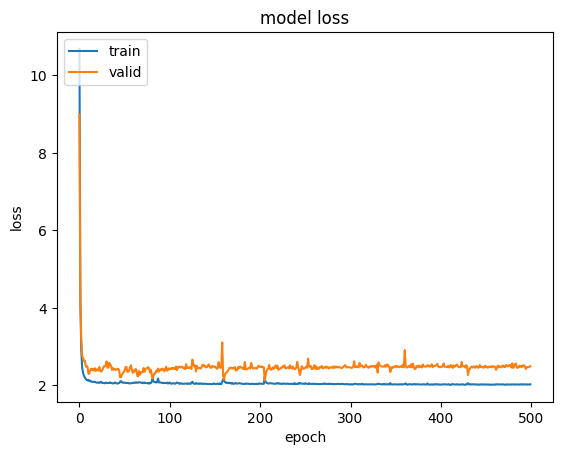

In [167]:
plt.plot(train_loss)
plt.plot(valid_loss)
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'valid'], loc='upper left')
# plt.ylim(0, 1)
plt.show()

## Model

In [167]:
returns = petr3["Return"]
returns.dropna(inplace=True)
original_len = returns.shape[0]
original_len

6144

In [168]:
returns.head(3)

Date
2000-01-04   -0.056123
2000-01-05    0.013514
2000-01-06   -0.008000
Name: Return, dtype: float64

In [169]:
# Convert the series to a supervised learning problem with a window of size 1
def create_lstm_dataset(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

window_size = 1
X, y = create_lstm_dataset(returns.values, window_size)

print("X:", X)
print("y:", y)
print(X.shape)

X: [[-0.05612256]
 [ 0.01351357]
 [-0.00799994]
 ...
 [ 0.03356068]
 [-0.00633585]
 [ 0.02019137]]
y: [ 0.01351357 -0.00799994  0.00806446 ... -0.00633585  0.02019137
 -0.00234378]
(6143, 1)


In [170]:
# Reshape X to be [samples, time_steps, features]
X = X.reshape((X.shape[0], window_size, 1))

print("X reshaped:", X.shape)


X reshaped: (6143, 1, 1)


In [171]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [172]:
model = Sequential([
    layers.LSTM(10, return_sequences=True, input_shape=(window_size, 1)),  # (time steps, features)
    layers.Dense(1)
])

model.compile(loss="mae", optimizer="adam")
model.summary()

/usr/local/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 1, 10)          │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1, 1)           │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

In [173]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=20,
    restore_best_weights=True
)

model.fit(X_train, y_train, epochs=200, validation_data=(X_test, y_test), verbose=1)

Epoch 1/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0191 - val_loss: 0.0195
Epoch 2/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0189 - val_loss: 0.0194
Epoch 3/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0190 - val_loss: 0.0194
Epoch 4/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0191 - val_loss: 0.0194
Epoch 5/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0189 - val_loss: 0.0195
Epoch 6/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0190 - val_loss: 0.0195
Epoch 7/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0189 - val_loss: 0.0194
Epoch 8/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0190 - val_loss: 0.0194
Epoch 9/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0187 - val_loss: 0.0194
Epoch 10/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0190 - val_loss: 0.0194
Epoch 11/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0186 - val_loss: 0.0195
Epoch 12/200
154/154 ━━━━━━━━━━━━━━━━━━━━